# Otimização de Threshold - Passos Mágicos



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    precision_recall_curve, PrecisionRecallDisplay
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
MIN_PRECISION = 0.70
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

## 1. Preparação dos Dados e Treinamento

In [2]:
df = pd.read_csv('../backend/data/processed/train_data.csv')

TARGET = 'RISCO_DEFASAGEM'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")

Treino: 411 | Validação: 137 | Teste: 138


In [3]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = [col for col in X.columns if col not in cat_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop'
)

modelo = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

modelo.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


## 2. Curva Precision-Recall



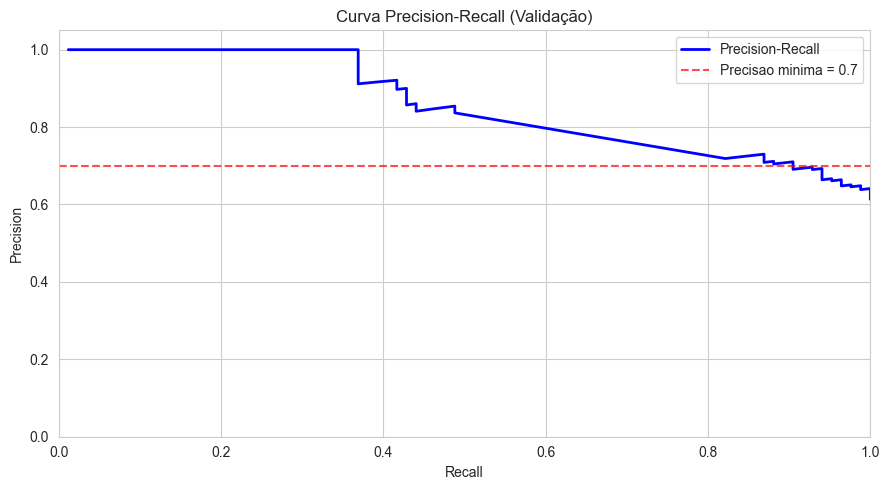

In [4]:
y_proba_val = modelo.predict_proba(X_val)[:, 1]

precisoes, recalls, thresholds = precision_recall_curve(y_val, y_proba_val)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recalls[:-1], precisoes[:-1], 'b-', lw=2, label='Precision-Recall')
ax.axhline(MIN_PRECISION, color='red', linestyle='--', alpha=0.7,
           label=f'Precisao minima = {MIN_PRECISION}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall (Validação)')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Varredura de Thresholds



In [5]:
grade = np.arange(0.10, 0.95, 0.05)

resultados = []
for thr in grade:
    y_pred = (y_proba_val >= thr).astype(int)
    resultados.append({
        'threshold':  round(float(thr), 2),
        'recall':     recall_score(y_val, y_pred, zero_division=0),
        'precision':  precision_score(y_val, y_pred, zero_division=0),
        'f1':         f1_score(y_val, y_pred, zero_division=0),
        'n_positivos': int(y_pred.sum()),
    })

df_thr = pd.DataFrame(resultados).set_index('threshold').round(3)
print(df_thr.to_string())

           recall  precision     f1  n_positivos
threshold                                       
0.10        1.000      0.641  0.781          131
0.15        0.988      0.638  0.776          130
0.20        0.940      0.669  0.782          118
0.25        0.905      0.697  0.788          109
0.30        0.881      0.705  0.783          105
0.35        0.869      0.723  0.789          101
0.40        0.869      0.723  0.789          101
0.45        0.845      0.724  0.780           98
0.50        0.488      0.837  0.617           49
0.55        0.452      0.844  0.589           45
0.60        0.429      0.900  0.581           40
0.65        0.393      0.917  0.550           36
0.70        0.369      0.969  0.534           32
0.75        0.333      1.000  0.500           28
0.80        0.333      1.000  0.500           28
0.85        0.262      1.000  0.415           22
0.90        0.202      1.000  0.337           17


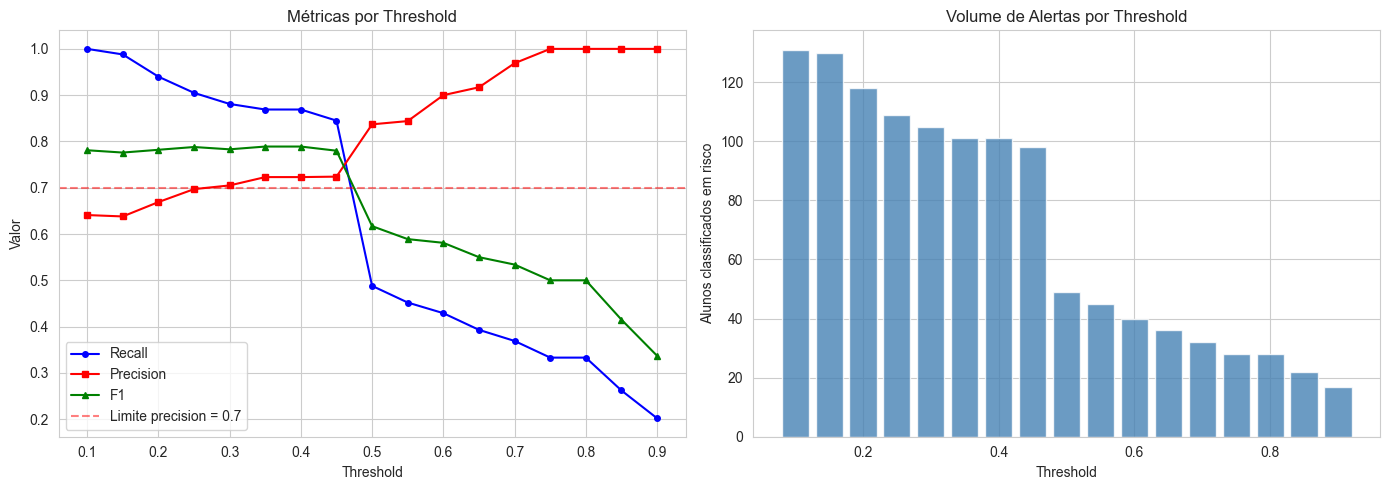

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: recall e precision por threshold
ax = axes[0]
ax.plot(df_thr.index, df_thr['recall'],    'b-o', ms=4, label='Recall')
ax.plot(df_thr.index, df_thr['precision'], 'r-s', ms=4, label='Precision')
ax.plot(df_thr.index, df_thr['f1'],        'g-^', ms=4, label='F1')
ax.axhline(MIN_PRECISION, color='red', linestyle='--', alpha=0.5,
           label=f'Limite precision = {MIN_PRECISION}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Valor')
ax.set_title('Métricas por Threshold')
ax.legend()

# Grafico 2: número de alunos classificados como em risco
ax2 = axes[1]
ax2.bar(df_thr.index, df_thr['n_positivos'], width=0.04, color='steelblue', alpha=0.8)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Alunos classificados em risco')
ax2.set_title('Volume de Alertas por Threshold')

plt.tight_layout()
plt.show()

## 4. Seleção do Threshold Otimo

In [7]:
# Filtro: só candidatos com precision >= 0.70
candidatos = df_thr[df_thr['precision'] >= MIN_PRECISION]

print(f"Thresholds com precision >= {MIN_PRECISION}:")
print(candidatos.to_string())

# Entre os candidatos, escolho o que maximiza o recall
melhor = candidatos.loc[candidatos['recall'].idxmax()]
threshold_otimo = melhor.name

print(f"\nThreshold escolhido: {threshold_otimo}")
print(f"  Recall:    {melhor['recall']:.3f}")
print(f"  Precision: {melhor['precision']:.3f}")
print(f"  F1:        {melhor['f1']:.3f}")

Thresholds com precision >= 0.7:
           recall  precision     f1  n_positivos
threshold                                       
0.30        0.881      0.705  0.783          105
0.35        0.869      0.723  0.789          101
0.40        0.869      0.723  0.789          101
0.45        0.845      0.724  0.780           98
0.50        0.488      0.837  0.617           49
0.55        0.452      0.844  0.589           45
0.60        0.429      0.900  0.581           40
0.65        0.393      0.917  0.550           36
0.70        0.369      0.969  0.534           32
0.75        0.333      1.000  0.500           28
0.80        0.333      1.000  0.500           28
0.85        0.262      1.000  0.415           22
0.90        0.202      1.000  0.337           17

Threshold escolhido: 0.3
  Recall:    0.881
  Precision: 0.705
  F1:        0.783


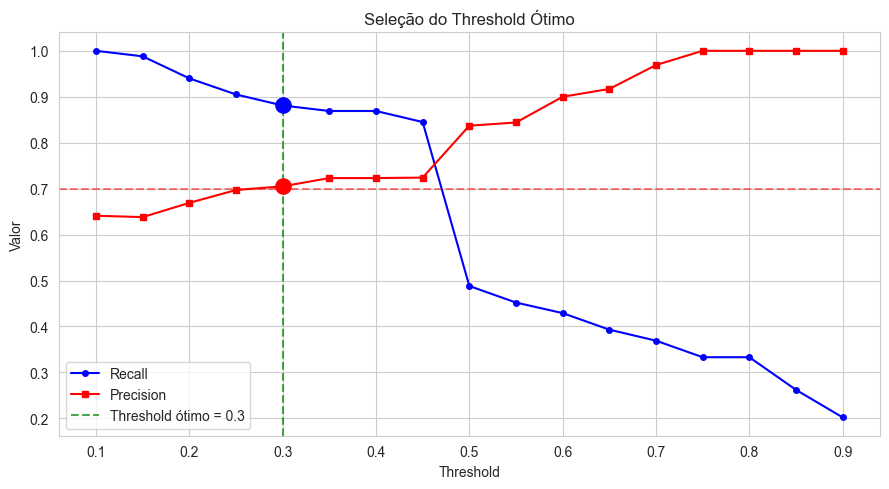

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_thr.index, df_thr['recall'],    'b-o', ms=4, label='Recall')
ax.plot(df_thr.index, df_thr['precision'], 'r-s', ms=4, label='Precision')
ax.axhline(MIN_PRECISION, color='red', linestyle='--', alpha=0.5)
ax.axvline(threshold_otimo, color='green', linestyle='--', alpha=0.7,
           label=f'Threshold ótimo = {threshold_otimo}')

ax.scatter([threshold_otimo], [melhor['recall']],    color='blue',  s=120, zorder=5)
ax.scatter([threshold_otimo], [melhor['precision']], color='red',   s=120, zorder=5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Valor')
ax.set_title('Seleção do Threshold Ótimo')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Avaliação Final no Conjunto de Teste



In [9]:
y_proba_test = modelo.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= threshold_otimo).astype(int)

recall_test    = recall_score(y_test, y_pred_test, zero_division=0)
precision_test = precision_score(y_test, y_pred_test, zero_division=0)
f1_test        = f1_score(y_test, y_pred_test, zero_division=0)

vp = int((y_pred_test * y_test.values).sum())

print("=== Resultado Final (Teste) ===")
print(f"Threshold:  {threshold_otimo}")
print(f"Recall:     {recall_test:.3f}")
print(f"Precision:  {precision_test:.3f}")
print(f"F1-score:   {f1_test:.3f}")
print(f"\nAlertas emitidos (preditos em risco): {y_pred_test.sum()}")
print(f"Casos reais de risco no teste:        {y_test.sum()}")
print(f"Identificados corretamente (VP):      {vp}")
print(f"Falsos alarmes (FP):                  {y_pred_test.sum() - vp}")

=== Resultado Final (Teste) ===
Threshold:  0.3
Recall:     0.929
Precision:  0.667
F1-score:   0.776

Alertas emitidos (preditos em risco): 117
Casos reais de risco no teste:        84
Identificados corretamente (VP):      78
Falsos alarmes (FP):                  39


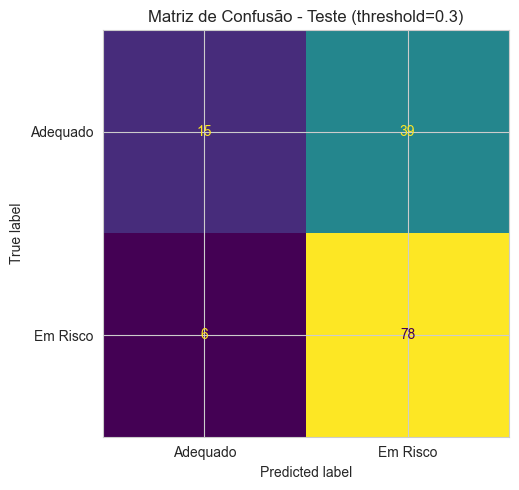

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Adequado', 'Em Risco'],
    colorbar=False,
    ax=ax
)
ax.set_title(f'Matriz de Confusão - Teste (threshold={threshold_otimo})')
plt.tight_layout()
plt.show()

## 6. Conclusão

**Threshold final: 0.30**

Com esse ponto de corte, o modelo no conjunto de teste:
- Identifica ~92% dos alunos realmente em risco (recall)
- Com uma taxa de acerto de ~67% nas predições positivas (precision)
- F1-score de ~0.78

O tradeoff e aceitável dado o contexto: prefiro que a equipe pedagógica verifique
alguns falsos alarmes do que deixar alunos em risco sem atenção.

Esse threshold (0.30) e o valor configurado em `backend/src/config.py` e utilizado
pela API de predicao.